In [ ]:
!pip install tensorflow
!pip install opencv-python
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install scikit-learn
!pip install kagglehub

In [ ]:
import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))

[]


In [ ]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"dishadevgirkar26","key":"77475710e94ba51d6b83f62c4358dc72"}'}

In [ ]:
!mkdir -p ~/.kaggle

!cp kaggle.json ~/.kaggle/

!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d dansbecker/food-101

Dataset URL: https://www.kaggle.com/datasets/dansbecker/food-101
License(s): other
100% 9.38G/9.38G [01:34<00:00, 107MB/s]



In [ ]:
import os

print(os.listdir('/content/food101'))

['food-101', 'food-101.zip']


In [ ]:
print(os.listdir('/content/food101/food-101'))

['__MACOSX', 'food-101']


In [ ]:
print(os.listdir('/content/food101/food-101/food-101'))

['README.txt', 'meta', 'license_agreement.txt', '.DS_Store', 'images']


In [ ]:
DATASET_PATH = "/content/food101/food-101/food-101/images"

In [ ]:
import os

classes = [
    c for c in os.listdir(DATASET_PATH)
    if not c.startswith('.')
]

print("Total Classes:",len(classes))

Total Classes: 101


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.applications import MobileNetV2

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D
)

In [ ]:
IMG_SIZE = 224

BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(224,224),
    batch_size=BATCH_SIZE,
    subset="training",
    class_mode="categorical"
)

val_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(224,224),
    batch_size=BATCH_SIZE,
    subset="validation",
    class_mode="categorical"
)

Found 80800 images belonging to 101 classes.
Found 20200 images belonging to 101 classes.


In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

In [ ]:
model = Sequential([
    base_model,

    GlobalAveragePooling2D(),

    Dense(
        512,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        101,
        activation='softmax'
    )
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 2447s 968ms/step - accuracy: 0.3473 - loss: 2.6771 - val_accuracy: 0.4993 - val_loss: 2.0006
Epoch 2/5
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 2495s 988ms/step - accuracy: 0.4377 - loss: 2.2431 - val_accuracy: 0.5144 - val_loss: 1.9328
Epoch 3/5
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 2518s 997ms/step - accuracy: 0.4613 - loss: 2.1327 - val_accuracy: 0.5198 - val_loss: 1.9070
Epoch 4/5
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 2540s 1s/step - accuracy: 0.4762 - loss: 2.0621 - val_accuracy: 0.5318 - val_loss: 1.8769
Epoch 5/5
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 2526s 1s/step - accuracy: 0.4884 - loss: 1.9971 - val_accuracy: 0.5313 - val_loss: 1.8697


In [ ]:
model.save("food_classifier.h5")

In [ ]:
from google.colab import files

files.download("food_classifier.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

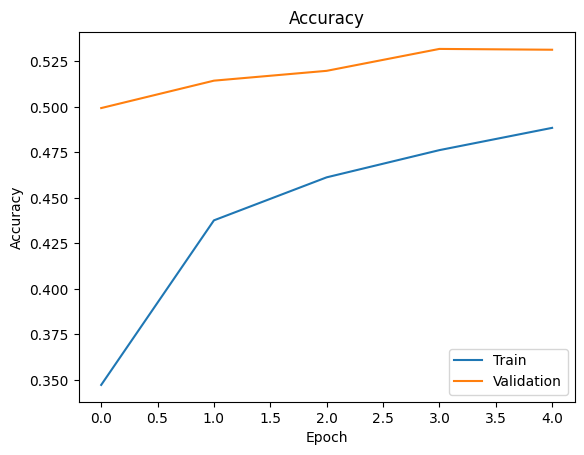

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend([
    "Train",
    "Validation"
])

plt.show()

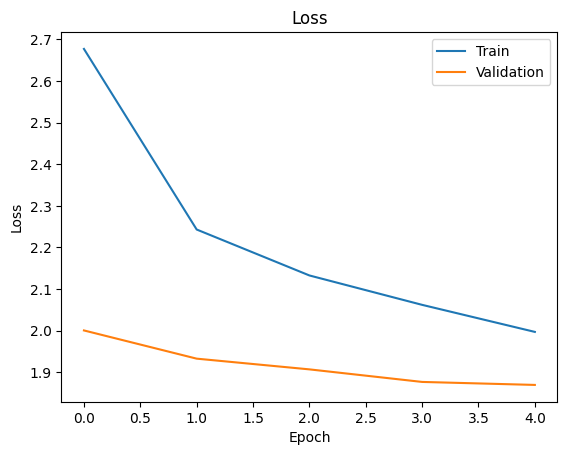

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend([
    "Train",
    "Validation"
])

plt.show()

In [ ]:
from google.colab import files

uploaded = files.upload()


Saving pizza.jpg to pizza.jpg


In [ ]:
from tensorflow.keras.preprocessing import image

img_path = list(uploaded.keys())[0]

img = image.load_img(
    img_path,
    target_size=(224,224)
)

img_array = image.img_to_array(img)

img_array = img_array/255.0

img_array = np.expand_dims(
    img_array,
    axis=0
)

prediction = model.predict(img_array)

pred_index = np.argmax(prediction)

class_names = list(
    train_generator.class_indices.keys()
)

food_name = class_names[pred_index]

print("Food:",food_name)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Food: pizza


In [ ]:
calorie_dict = {
    "pizza":285,
    "hamburger":295,
    "ice_cream":207,
    "sushi":200,
    "ramen":436,
    "fried_rice":333,
    "cheesecake":321,
    "donuts":452,
    "omelette":154
}

In [ ]:
calories = calorie_dict.get(
    food_name,
    "Unknown"
)

print("Food:",food_name)

print(
    "Estimated Calories:",
    calories
)

Food: pizza
Estimated Calories: 285
